In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
# ----------------------------
# 1. Load and prepare data
# ----------------------------
df_raw = pd.read_csv('WorldEnergy.csv')

# Selected Southeast Asian countries
selected_countries = [
    'Indonesia', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam'
]

# Keep necessary columns
target_columns = [
    'country', 'year','low_carbon_energy_per_capita', 'low_carbon_consumption', 'low_carbon_share_energy'
]

# Filter for countries and requested metrics, then drop rows with missing values
df = df_raw[df_raw['country'].isin(selected_countries)][target_columns].dropna().copy()

# Keep years from 2000 onward
df = df[df['year'] >= 2000].reset_index(drop=True)

# ----------------------------
# 2. Assign Categories (GDP Level and Period)
# ----------------------------

# Assign GDP level based on country
gdp_mapping = {
    'Singapore': 'High',
    'Malaysia': 'Middle',
    'Thailand': 'Middle',
    'Indonesia': 'Low',
    'Philippines': 'Low',
    'Vietnam': 'Low'
}
df['gdp_level'] = df['country'].map(gdp_mapping)

# Assign Period based on year
df['period'] = df['year'].apply(lambda x: 'Early' if 2000 <= x <= 2010 else 'Recent')

print("Data Preparation Complete.")
display(df.head())

Data Preparation Complete.


,country,year,low_carbon_energy_per_capita,low_carbon_consumption,low_carbon_share_energy,gdp_level,period
0,Indonesia,2000,199.227,43.048,3.699,Low,Early
1,Indonesia,2001,233.020,51.054,4.096,Low,Early
2,Indonesia,2002,210.385,46.724,3.647,Low,Early
3,Indonesia,2003,197.675,44.486,3.195,Low,Early
4,Indonesia,2004,206.412,47.047,3.415,Low,Early


In [ ]:
# ----------------------------
# 3. One-Way ANOVA: GDP Level vs Low Carbon Energy
# ----------------------------
from scipy import stats

# Group data by GDP level
groups = [group['low_carbon_energy_per_capita'].values for name, group in df.groupby('gdp_level')]

# Perform One-Way ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print("=== One-Way ANOVA (GDP Level) ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

# Post-hoc Tukey HSD test
if p_val < 0.05:
    tukey = pairwise_tukeyhsd(endog=df['low_carbon_energy_per_capita'],
                              groups=df['gdp_level'],
                              alpha=0.05)
    print("\nTukey HSD Post-hoc Test:")
    print(tukey)

=== One-Way ANOVA (GDP Level) ===
F-statistic: 8.5691
p-value: 3.0192e-04

Tukey HSD Post-hoc Test:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
  High    Low  397.396 0.0325    26.7  768.0919   True
  High Middle 682.0704 0.0002 288.888 1075.2528   True
   Low Middle 284.6744 0.0589 -8.3865  577.7353  False
------------------------------------------------------


In [ ]:
# ----------------------------
# 4. Two-Way ANOVA: GDP Level and Period
# ----------------------------

# Define the model to analyze the effect of GDP Level and Period on Low Carbon Energy
# C() denotes categorical variables in the formula
model = ols('low_carbon_energy_per_capita ~ C(gdp_level) * C(period)', data=df).fit()

# Perform Two-Way ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA (GDP Level * Period) ===")
print(anova_table)

=== Two-Way ANOVA (GDP Level * Period) ===
                              sum_sq     df          F        PR(>F)
C(gdp_level)            7.876866e+06    2.0  11.984706  1.532940e-05
C(period)               1.732072e+07    1.0  52.707186  2.224542e-11
C(gdp_level):C(period)  2.919909e+06    2.0   4.442662  1.342029e-02
Residual                4.732151e+07  144.0        NaN           NaN


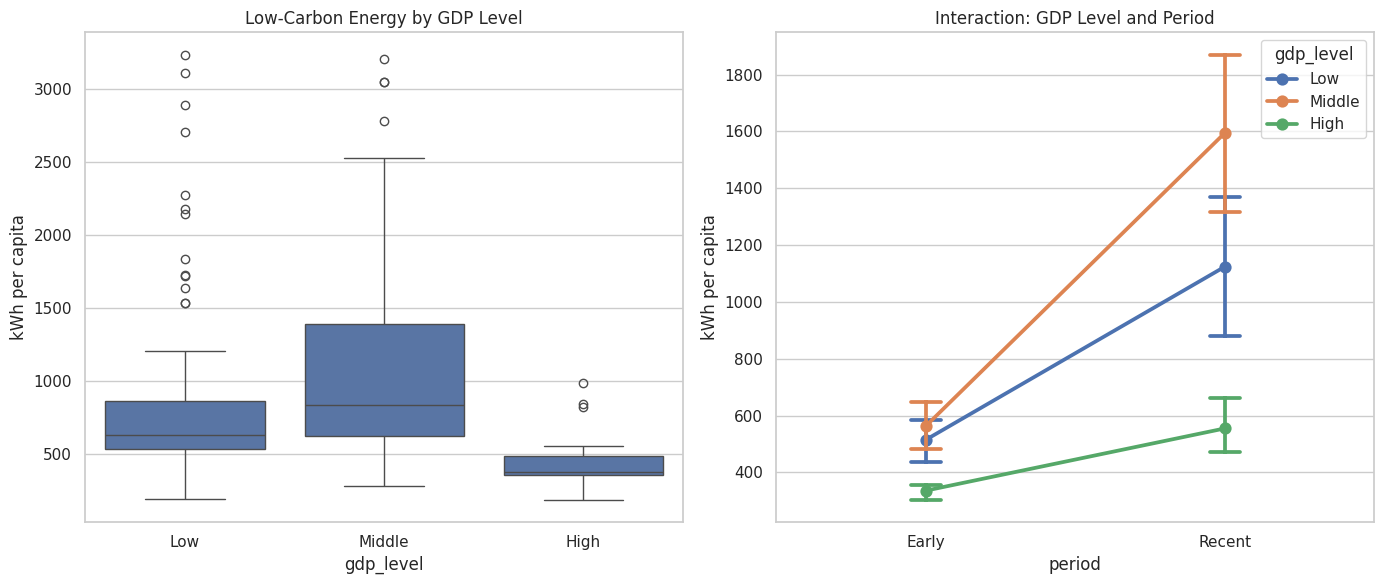

In [ ]:
# ----------------------------
# 5. Visualizations
# ----------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Boxplot for GDP Level
plt.subplot(1, 2, 1)
sns.boxplot(x='gdp_level', y='low_carbon_energy_per_capita', data=df, order=['Low', 'Middle', 'High'])
plt.title('Low-Carbon Energy by GDP Level')
plt.ylabel('kWh per capita')

# Interaction Plot for Two-Way ANOVA
plt.subplot(1, 2, 2)
sns.pointplot(x='period', y='low_carbon_energy_per_capita', hue='gdp_level',
              data=df, order=['Early', 'Recent'], capsize=.1)
plt.title('Interaction: GDP Level and Period')
plt.ylabel('kWh per capita')

plt.tight_layout()
plt.show()

In [ ]:
# Normality Test (Shapiro-Wilk) on residuals
# if p > 0.05 → residuals are normally distributed.

# Using the 'model' variable defined in the Two-Way ANOVA step
residuals = model.resid
shapiro_test = stats.shapiro(residuals)

print("=== Shapiro-Wilk Test (Residuals) ===")
print(f"Statistic: {shapiro_test.statistic:.4f}")
print(f"p-value: {shapiro_test.pvalue:.4e}")

if shapiro_test.pvalue > 0.05:
    print("Result: Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Result: Residuals do not appear to be normally distributed (reject H0).")

=== Shapiro-Wilk Test (Residuals) ===
Statistic: 0.8961
p-value: 7.9662e-09
Result: Residuals do not appear to be normally distributed (reject H0).


In [ ]:
# Homogeneity of Variance (Levene’s Test)
# p > 0.05 → equal variances assumption holds.

# Grouping the low carbon energy data by gdp_level for the test
groups = [group['low_carbon_energy_per_capita'].values for name, group in df.groupby('gdp_level')]

levene_test = stats.levene(*groups)

print("=== Levene’s Test (Homogeneity of Variance) ===")
print(f"Statistic: {levene_test.statistic:.4f}")
print(f"p-value: {levene_test.pvalue:.4e}")

if levene_test.pvalue > 0.05:
    print("Result: Variances are equal across groups (fail to reject H0).")
else:
    print("Result: Variances are not equal across groups (reject H0).")

=== Levene’s Test (Homogeneity of Variance) ===
Statistic: 5.3693
p-value: 5.6156e-03
Result: Variances are not equal across groups (reject H0).
